# 01. EGIS hybrid landcover cache 생성

`00`이 만든 ROI에 대해 EGIS WMS를 불러와 최종 토지피복 cache를 만든다.

고정 정책:
- ROI: 후보 CSV의 98개 도시/ROI.
- EGIS 정책 그룹: 7개.
  - 2016-2018 분석연도 → `lv3_10th_g`, 2018 측량 / 2019 공시.
  - 2019 → `lv3_2020_g`, 2019 측량 / 2020 공시.
  - 2020 → `lv3_2021_g`, 2020 측량 / 2021 공시.
  - 2021 → `lv2_2022y`, 2021 측량 / 2022 공시.
  - 2022 → `lv2_2023y`, 2022 측량 / 2023 공시.
  - 2023 → `lv2_2024y`, 2023 측량 / 2024 공시.
  - 2024-2025 분석연도 → `lv2_2025y`, 2024 측량 / 2025 공시.
- 총 cache 후보: `98 ROI × 7 정책그룹 = 686`.
- 토지피복 정형화: 시가지와 수역은 중분류, 나머지는 대분류.
- RGB 판정은 4배 해상도 WMS에서 엄격하게 수행한다. 중분류/세분류 모두 최대 channel tolerance 10로 제한한다.
- RGB 미인지/원천 nodata는 unknown으로 남긴 뒤 최종 cache에서 채운다.
- 2019-2021 unknown은 같은 픽셀의 2022 cache를 4표로, 주변 8방향 픽셀을 각 1표로 카운트해 최빈값으로 채운다.
- 그 외 연도 unknown은 주변 최빈값으로 끝까지 채운다.
- 최종 cache가 완성되면 `egis_cache_ready.json`을 쓴다. 02는 이 파일 없이는 실행하지 않는다.


In [1]:
# 필요하면 먼저 실행
%pip install -q numpy pandas requests pyproj pillow matplotlib tqdm

from __future__ import annotations

from pathlib import Path
from io import BytesIO
import json
import time
import warnings

from PIL import Image
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from pyproj import Transformer
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")


Note: you may need to restart the kernel to use updated packages.


## 1. 경로와 후보 확인


In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name in {"final", "attempt1", "attempt2", "attempt3"}:
    PROJECT_DIR = PROJECT_DIR.parent

ATTEMPT_DIR = PROJECT_DIR / "attempt3"
CANDIDATE_CSV = ATTEMPT_DIR / "lst_candidates.csv"
DATA_DIR = ATTEMPT_DIR / "lst_dataset"
EGIS_ROOT = DATA_DIR / "egis_policy"
RAW_CACHE_DIR = DATA_DIR / "egis_raw_policy_cache"
FINAL_CACHE_DIR = DATA_DIR / "egis_cache"
PREVIEW_DIR = EGIS_ROOT / "nodata_review_previews"
REPORT_DIR = EGIS_ROOT / "reports"
READY_FILE = DATA_DIR / "egis_cache_ready.json"
NODATA_PREVIEW_CSV = REPORT_DIR / "egis_nodata_preview_cases.csv"
RAW_SUMMARY_CSV = REPORT_DIR / "egis_raw_policy_summary.csv"
FINAL_SUMMARY_CSV = REPORT_DIR / "egis_final_cache_summary.csv"

for d in [DATA_DIR, EGIS_ROOT, RAW_CACHE_DIR, FINAL_CACHE_DIR, PREVIEW_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GRID_N = 256
PIXEL_SIZE_M = 60
CRS_BASE = "EPSG:32653"
REQUEST_TIMEOUT = 180
EGIS_WMS_URL = "https://api.mcee.go.kr/geoserver/wms?"

if not CANDIDATE_CSV.exists():
    raise FileNotFoundError(f"candidate csv missing: {CANDIDATE_CSV}. Run 00 first.")

candidates = pd.read_csv(CANDIDATE_CSV)
candidates["date"] = pd.to_datetime(candidates["date"])
candidates["year"] = candidates["date"].dt.year
required_cols = {"city", "latitude", "longitude", "date", "year"}
missing_cols = required_cols - set(candidates.columns)
if missing_cols:
    raise ValueError(f"candidate columns missing: {sorted(missing_cols)}")

print("candidate rows:", len(candidates))
print("cities:", candidates["city"].nunique())
print("year range:", int(candidates["year"].min()), "-", int(candidates["year"].max()))
if "split" in candidates.columns:
    print("split counts:", candidates["split"].value_counts().sort_index().to_dict())
if "season" in candidates.columns:
    print("season counts:", candidates["season"].value_counts().sort_index().to_dict())


candidate rows: 3919
cities: 98
year range: 2016 - 2025
split counts: {'test': 482, 'train': 2834, 'val': 603}
season counts: {'autumn': 980, 'spring': 980, 'summer': 979, 'winter': 980}


## 2. EGIS 정책 그룹


In [3]:
EGIS_POLICY_TABLE = pd.DataFrame([
    {"policy_year": 2018, "analysis_year_min": 2016, "analysis_year_max": 2018, "survey_year": 2018, "announced_year": 2019, "source_key": "lv3_10th_g", "source_level": "lv3", "layer": "EGIS:lv3_10th_g"},
    {"policy_year": 2019, "analysis_year_min": 2019, "analysis_year_max": 2019, "survey_year": 2019, "announced_year": 2020, "source_key": "lv3_2020_g", "source_level": "lv3", "layer": "EGIS:lv3_2020_g"},
    {"policy_year": 2020, "analysis_year_min": 2020, "analysis_year_max": 2020, "survey_year": 2020, "announced_year": 2021, "source_key": "lv3_2021_g", "source_level": "lv3", "layer": "EGIS:lv3_2021_g"},
    {"policy_year": 2021, "analysis_year_min": 2021, "analysis_year_max": 2021, "survey_year": 2021, "announced_year": 2022, "source_key": "lv2_2022y", "source_level": "lv2", "layer": "EGIS:lv2_2022y"},
    {"policy_year": 2022, "analysis_year_min": 2022, "analysis_year_max": 2022, "survey_year": 2022, "announced_year": 2023, "source_key": "lv2_2023y", "source_level": "lv2", "layer": "EGIS:lv2_2023y"},
    {"policy_year": 2023, "analysis_year_min": 2023, "analysis_year_max": 2023, "survey_year": 2023, "announced_year": 2024, "source_key": "lv2_2024y", "source_level": "lv2", "layer": "EGIS:lv2_2024y"},
    {"policy_year": 2024, "analysis_year_min": 2024, "analysis_year_max": 2025, "survey_year": 2024, "announced_year": 2025, "source_key": "lv2_2025y", "source_level": "lv2", "layer": "EGIS:lv2_2025y"},
])
EGIS_BUILD_POLICY_ORDER = [2022, 2023, 2024, 2019, 2020, 2021, 2018]
EGIS_REFERENCE_POLICY_YEAR = 2022
EGIS_REFERENCE_FILL_YEARS = {2019, 2020, 2021}
EGIS_REFERENCE_FILL_WEIGHT = 4

def analysis_year_to_policy_year(year):
    year = int(year)
    hit = EGIS_POLICY_TABLE[(EGIS_POLICY_TABLE["analysis_year_min"] <= year) & (year <= EGIS_POLICY_TABLE["analysis_year_max"])]
    if hit.empty:
        raise ValueError(f"analysis year outside EGIS policy: {year}")
    return int(hit.iloc[0]["policy_year"])

city_cols = [c for c in ["city", "latitude", "longitude", "roi_group", "water_context", "terrain_context"] if c in candidates.columns]
city_rows = candidates.sort_values(["city", "date"]).groupby("city", as_index=False).first()[city_cols]
policy_groups = city_rows.assign(_k=1).merge(EGIS_POLICY_TABLE.assign(_k=1), on="_k").drop(columns="_k")
policy_groups["build_order"] = policy_groups["policy_year"].map({year: i for i, year in enumerate(EGIS_BUILD_POLICY_ORDER)})
policy_groups = policy_groups.sort_values(["build_order", "city"]).reset_index(drop=True)

candidate_policy_groups = candidates.assign(policy_year=candidates["year"].map(analysis_year_to_policy_year))[["city", "policy_year"]].drop_duplicates()
expected_groups = len(city_rows) * len(EGIS_POLICY_TABLE)
print("ROI cities:", len(city_rows))
print("policy periods:", len(EGIS_POLICY_TABLE))
print("expected policy cache groups:", len(policy_groups))
print("candidate-covered city-policy groups:", len(candidate_policy_groups))
if len(policy_groups) != expected_groups:
    raise RuntimeError(f"expected {expected_groups} policy groups, got {len(policy_groups)}")
if len(candidate_policy_groups) != expected_groups:
    raise RuntimeError(f"candidate CSV does not cover all {expected_groups} city-policy groups: {len(candidate_policy_groups)}")
display(EGIS_POLICY_TABLE)


ROI cities: 98
policy periods: 7
expected policy cache groups: 686
candidate-covered city-policy groups: 686


,policy_year,analysis_year_min,analysis_year_max,survey_year,announced_year,source_key,source_level,layer
0,2018,2016,2018,2018,2019,lv3_10th_g,lv3,EGIS:lv3_10th_g
1,2019,2019,2019,2019,2020,lv3_2020_g,lv3,EGIS:lv3_2020_g
2,2020,2020,2020,2020,2021,lv3_2021_g,lv3,EGIS:lv3_2021_g
3,2021,2021,2021,2021,2022,lv2_2022y,lv2,EGIS:lv2_2022y
4,2022,2022,2022,2022,2023,lv2_2023y,lv2,EGIS:lv2_2023y
5,2023,2023,2023,2023,2024,lv2_2024y,lv2,EGIS:lv2_2024y
6,2024,2024,2025,2024,2025,lv2_2025y,lv2,EGIS:lv2_2025y


## 3. grid, 색상표, hybrid 분류


In [4]:
def make_patch_grid(center_lat, center_lon, grid_n=GRID_N, pixel_size_m=PIXEL_SIZE_M, crs_base=CRS_BASE):
    to_xy = Transformer.from_crs("EPSG:4326", crs_base, always_xy=True)
    cx, cy = to_xy.transform(float(center_lon), float(center_lat))
    half = grid_n * pixel_size_m / 2
    return {"n": grid_n, "pixel_size": pixel_size_m, "crs": crs_base, "left": cx - half, "right": cx + half, "bottom": cy - half, "top": cy + half}

LV1_CLASSES = [100, 200, 300, 400, 500, 600, 700]
URBAN_LV2_CLASSES = [110, 120, 130, 140, 150, 160]
WATER_LV2_CLASSES = [710, 720]
OTHER_LV1_CLASSES = [200, 300, 400, 500, 600]
HYBRID_CLASSES = URBAN_LV2_CLASSES + OTHER_LV1_CLASSES + WATER_LV2_CLASSES
HYBRID_CLASS_NAMES = {
    110: "urban_residential", 120: "urban_industrial", 130: "urban_commercial", 140: "urban_cultural_public", 150: "urban_transportation", 160: "urban_mixed",
    200: "agriculture", 300: "forest", 400: "grassland", 500: "wetland", 600: "barren", 710: "water_inland", 720: "water_marine",
}
HYBRID_FILL_PRIORITY = {cls: i for i, cls in enumerate([720, 710, 110, 120, 130, 140, 150, 160, 300, 200, 400, 500, 600])}

LV1_COLORS = {100: (255, 0, 0), 200: (238, 233, 7), 300: (42, 75, 45), 400: (57, 150, 38), 500: (124, 34, 126), 600: (89, 206, 202), 700: (6, 2, 250)}
LV2_COLORS = {
    110: (254, 230, 194), 120: (192, 132, 132), 130: (237, 131, 184), 140: (246, 113, 138), 150: (247, 65, 42), 160: (246, 177, 18),
    210: (255, 255, 191), 220: (247, 249, 102), 230: (223, 220, 115), 240: (184, 177, 44), 250: (184, 145, 18),
    310: (51, 160, 44), 320: (10, 79, 64), 330: (51, 102, 51), 410: (161, 213, 148), 420: (96, 126, 51),
    510: (180, 167, 208), 520: (153, 116, 153), 610: (193, 219, 236), 620: (159, 242, 255), 710: (62, 167, 255), 720: (23, 57, 255),
}
LV3_COLORS = {
    111: (254, 230, 194), 112: (223, 193, 111), 121: (192, 132, 132), 131: (237, 131, 184), 132: (223, 176, 164),
    141: (246, 113, 138), 151: (229, 38, 254), 152: (197, 50, 81), 153: (252, 4, 78), 154: (247, 65, 42), 155: (115, 0, 0),
    161: (246, 177, 18), 162: (255, 122, 0), 163: (199, 88, 27), 211: (255, 255, 191), 212: (244, 230, 168),
    221: (247, 249, 102), 222: (245, 228, 10), 231: (223, 220, 115), 241: (184, 177, 44), 251: (184, 145, 18), 252: (170, 100, 0),
    311: (51, 160, 44), 321: (10, 79, 64), 331: (51, 102, 51), 411: (161, 213, 148), 421: (128, 228, 90), 422: (113, 176, 90), 423: (96, 126, 51),
    511: (180, 167, 208), 521: (153, 116, 153), 522: (124, 30, 162), 611: (193, 219, 236), 612: (171, 197, 202), 613: (171, 182, 165),
    621: (88, 90, 138), 622: (123, 181, 172), 623: (159, 242, 255), 711: (62, 167, 255), 712: (93, 109, 255), 721: (23, 57, 255),
}
COLOR_TABLE_BY_LEVEL = {"lv1": LV1_COLORS, "lv2": LV2_COLORS, "lv3": LV3_COLORS}
EGIS_COLOR_MATCH_VERSION = "rgbtol_strict10_supersample4_marg8_announced_v1"
EGIS_MANUAL_NODATA_RULE_VERSION = "unknown_majority_8nbr_2022x4_v1"
WMS_COLOR_DISTANCE_THRESHOLD_BY_LEVEL = {"lv1": 18.0, "lv2": 18.0, "lv3": 18.0}
WMS_COLOR_CHANNEL_TOLERANCE_BY_LEVEL = {"lv1": 10.0, "lv2": 10.0, "lv3": 10.0}
WMS_COLOR_DISTANCE_RELAX_STEP = 5.0
WMS_COLOR_CHANNEL_RELAX_STEP = 3.0
WMS_COLOR_DISTANCE_MAX_BY_LEVEL = {"lv1": 18.0, "lv2": 18.0, "lv3": 18.0}
WMS_COLOR_CHANNEL_MAX_BY_LEVEL = {"lv1": 10.0, "lv2": 10.0, "lv3": 10.0}
WMS_COLOR_MARGIN_MIN_BY_LEVEL = {"lv1": 8.0, "lv2": 8.0, "lv3": 8.0}
WMS_SUPERSAMPLE = 4

def code_to_lv1(code):
    code = int(code)
    if code <= 0:
        return 0
    if code in LV1_CLASSES:
        return code
    return (code // 100) * 100

def code_to_lv2(code, level="lv3"):
    code = int(code)
    if code <= 0:
        return 0
    if level in {"lv1", "lv2"}:
        return code
    return (code // 10) * 10

def code_to_hybrid(code, level="lv3"):
    code = int(code)
    if code <= 0:
        return 0
    lv1 = code_to_lv1(code)
    lv2 = code_to_lv2(code, level)
    if lv1 == 100:
        return lv2 if lv2 in URBAN_LV2_CLASSES else 110
    if lv1 == 700:
        return lv2 if lv2 in WATER_LV2_CLASSES else 720
    if lv1 in OTHER_LV1_CLASSES:
        return lv1
    return 0

def hybrid_to_rgba(arr):
    out = np.zeros((*arr.shape, 4), dtype=np.uint8)
    colors = {**LV1_COLORS, **LV2_COLORS}
    for cls in HYBRID_CLASSES:
        m = arr == int(cls)
        out[m, :3] = np.array(colors.get(int(cls), (0, 0, 0)), dtype=np.uint8)
        out[m, 3] = 255
    out[arr == 0] = np.array([0, 0, 0, 255], dtype=np.uint8)
    return out


## 4. WMS 호출과 RGB 미인지 무상한 반복


In [5]:

def rgb_match_thresholds(level, attempt=0):
    return (
        WMS_COLOR_DISTANCE_THRESHOLD_BY_LEVEL[level] + attempt * WMS_COLOR_DISTANCE_RELAX_STEP,
        WMS_COLOR_CHANNEL_TOLERANCE_BY_LEVEL[level] + attempt * WMS_COLOR_CHANNEL_RELAX_STEP,
    )


def request_wms_image(layer_name, grid, scale=1):
    width = int(grid["n"] * scale)
    height = int(grid["n"] * scale)
    params = {
        "SERVICE": "WMS", "VERSION": "1.1.1", "REQUEST": "GetMap", "LAYERS": layer_name, "STYLES": "",
        "SRS": grid["crs"], "BBOX": f'{grid["left"]},{grid["bottom"]},{grid["right"]},{grid["top"]}',
        "WIDTH": width, "HEIGHT": height, "FORMAT": "image/png", "TRANSPARENT": "TRUE",
    }
    last_exc = None
    for attempt in range(1, 6):
        try:
            r = requests.get(EGIS_WMS_URL, params=params, timeout=REQUEST_TIMEOUT)
            content_type = r.headers.get("content-type", "")
            if not r.ok:
                raise RuntimeError(f"HTTP {r.status_code}: {r.text[:500]}")
            if "image" not in content_type.lower() and not r.content.startswith(bytes([137, 80, 78, 71])):
                raise RuntimeError(f"WMS did not return image: {content_type}; {r.text[:500]}")
            img = Image.open(BytesIO(r.content)).convert("RGBA")
            if img.size != (width, height):
                img = img.resize((width, height), Image.Resampling.NEAREST)
            return np.array(img)
        except Exception as exc:
            last_exc = exc
            wait = min(5 * attempt, 30)
            print(f"[EGIS WMS retry {attempt}/5] {layer_name}: {type(exc).__name__}: {exc}; wait {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"EGIS WMS failed for {layer_name}: {last_exc}")


def rgb_to_hybrid_landcover(rgba, level, attempt=0, chunk_pixels=200_000):
    rgb = rgba[..., :3].astype(np.float32).reshape(-1, 3)
    alpha = rgba[..., 3].reshape(-1)
    table = COLOR_TABLE_BY_LEVEL[level]
    codes = np.array(list(table.keys()), dtype=np.int16)
    colors = np.array([table[int(c)] for c in codes], dtype=np.float32)
    dist_thr, ch_thr = rgb_match_thresholds(level, attempt)

    n = rgb.shape[0]
    raw_flat = np.zeros(n, dtype=np.int16)
    dist_flat = np.full(n, np.inf, dtype=np.float32)
    absmax_flat = np.full(n, np.inf, dtype=np.float32)
    accepted_flat = np.zeros(n, dtype=np.uint8)

    for start in range(0, n, chunk_pixels):
        end = min(start + chunk_pixels, n)
        chunk = rgb[start:end]
        diff = chunk[:, None, :] - colors[None, :, :]
        dist_sq = np.sum(diff * diff, axis=-1)
        best_idx = np.argmin(dist_sq, axis=-1)
        best_dist = np.sqrt(dist_sq[np.arange(end - start), best_idx])
        if dist_sq.shape[1] > 1:
            second_sq = np.partition(dist_sq, 1, axis=-1)[:, 1]
            margin = np.sqrt(second_sq) - best_dist
        else:
            margin = np.full(end - start, np.inf, dtype=np.float32)
        best_absmax = np.max(np.abs(diff[np.arange(end - start), best_idx, :]), axis=-1)
        raw = codes[best_idx]
        margin_thr = WMS_COLOR_MARGIN_MIN_BY_LEVEL[level]
        accepted = (alpha[start:end] >= 128) & (best_dist <= dist_thr) & (best_absmax <= ch_thr) & (margin >= margin_thr)
        raw_flat[start:end] = raw.astype(np.int16)
        dist_flat[start:end] = best_dist.astype(np.float32)
        absmax_flat[start:end] = best_absmax.astype(np.float32)
        accepted_flat[start:end] = accepted.astype(np.uint8)

    hybrid_flat = np.zeros(n, dtype=np.int16)
    if accepted_flat.any():
        raw_to_hybrid = {int(code): int(code_to_hybrid(int(code), level)) for code in codes}
        accepted_idx = np.where(accepted_flat.astype(bool))[0]
        hybrid_flat[accepted_idx] = np.array([raw_to_hybrid[int(code)] for code in raw_flat[accepted_idx]], dtype=np.int16)

    shape = rgba.shape[:2]
    hybrid = hybrid_flat.reshape(shape)
    valid = (hybrid > 0).astype(np.float32)
    return (
        hybrid,
        valid,
        raw_flat.reshape(shape),
        dist_flat.reshape(shape),
        absmax_flat.reshape(shape),
        accepted_flat.reshape(shape),
    )


def classify_rgb_with_strict_unknown(rgba, level="lv3"):
    attempt = 0
    while True:
        hybrid, valid, raw_code, dist, absmax, accepted = rgb_to_hybrid_landcover(rgba, level, attempt)
        source_nodata = rgba[..., 3] < 128
        unrecognized = (~source_nodata) & (accepted == 0)
        ratio = float(unrecognized.mean())
        dist_thr, ch_thr = rgb_match_thresholds(level, attempt)
        if ratio == 0.0:
            return hybrid, valid, raw_code, source_nodata.astype(np.uint8), unrecognized.astype(np.uint8), dist, absmax, attempt + 1

        next_attempt = attempt + 1
        next_dist, next_ch = rgb_match_thresholds(level, next_attempt)
        max_dist = WMS_COLOR_DISTANCE_MAX_BY_LEVEL[level]
        max_ch = WMS_COLOR_CHANNEL_MAX_BY_LEVEL[level]
        if next_dist > max_dist or next_ch > max_ch:
            print(
                f"[EGIS RGB strict stop] unrecognized_ratio={ratio:.8f} "
                f"last_dist_threshold={dist_thr:.1f} last_channel_tolerance={ch_thr:.1f}; "
                "remaining pixels will be majority-filled"
            )
            return hybrid, valid, raw_code, source_nodata.astype(np.uint8), unrecognized.astype(np.uint8), dist, absmax, attempt + 1

        print(
            f"[EGIS RGB retry {next_attempt + 1}/strict] unrecognized_ratio={ratio:.8f} "
            f"next_dist_threshold={next_dist:.1f} next_channel_tolerance={next_ch:.1f}"
        )
        attempt = next_attempt


def _block_view_2d(arr, factor):
    if factor == 1:
        return arr[..., None]
    h, w = arr.shape
    h2 = (h // factor) * factor
    w2 = (w // factor) * factor
    if h2 != h or w2 != w:
        arr = arr[:h2, :w2]
    return arr.reshape(h2 // factor, factor, w2 // factor, factor).transpose(0, 2, 1, 3).reshape(h2 // factor, w2 // factor, factor * factor)


def block_mode_codes(arr, factor, classes, priority=None):
    if factor == 1:
        return arr.copy()
    blocks = _block_view_2d(arr, factor)
    out = np.zeros(blocks.shape[:2], dtype=arr.dtype)
    best_count = np.zeros(blocks.shape[:2], dtype=np.int16)
    priority = priority or {}
    ordered = sorted([int(c) for c in classes], key=lambda c: priority.get(c, 9999))
    for cls in ordered:
        counts = (blocks == int(cls)).sum(axis=-1).astype(np.int16)
        take = counts > best_count
        out[take] = int(cls)
        best_count[take] = counts[take]
    return out


def block_majority_bool(arr, factor):
    if factor == 1:
        return arr.astype(np.uint8).copy()
    blocks = _block_view_2d(arr.astype(np.uint8), factor)
    return (blocks.mean(axis=-1) >= 0.5).astype(np.uint8)


def block_median_float(arr, factor):
    if factor == 1:
        return arr.astype(np.float32).copy()
    blocks = _block_view_2d(arr.astype(np.float32), factor)
    return np.nanmedian(blocks, axis=-1).astype(np.float32)


def downsample_rgba_preview(rgba, out_n):
    img = Image.fromarray(rgba.astype(np.uint8), mode="RGBA")
    img = img.resize((out_n, out_n), Image.Resampling.NEAREST)
    return np.array(img, dtype=np.uint8)


def downsample_classification_to_grid(rgba_hr, hybrid_hr, raw_code_hr, source_nodata_hr, unrecognized_hr, dist_hr, absmax_hr, grid_n, factor, level="lv3"):
    class_priority = {0: 9999, **HYBRID_FILL_PRIORITY}
    raw_classes = [0] + [int(c) for c in COLOR_TABLE_BY_LEVEL[level].keys()]
    hybrid = block_mode_codes(hybrid_hr.astype(np.int16), factor, [0] + HYBRID_CLASSES, class_priority)
    raw_code = block_mode_codes(raw_code_hr.astype(np.int16), factor, raw_classes, {0: 9999})
    source_nodata = block_majority_bool(source_nodata_hr, factor)
    unrecognized = block_majority_bool(unrecognized_hr, factor)
    dist = block_median_float(dist_hr, factor)
    absmax = block_median_float(absmax_hr, factor)
    rgba = downsample_rgba_preview(rgba_hr, grid_n)

    # If most high-resolution pixels in a 60 m block are source nodata, keep it unknown here.
    # The final cache cell fills these by surrounding majority under the current policy.
    hybrid[source_nodata.astype(bool) | unrecognized.astype(bool)] = 0
    valid = (hybrid > 0).astype(np.float32)
    return rgba, hybrid, valid, raw_code, source_nodata, unrecognized, dist, absmax


## 5. 선택: source nodata 케이스 preview

이 셀은 확인용이다. 기본값은 꺼져 있다. 최종 cache 생성에는 필요 없다.


In [7]:
def raw_cache_path(city, policy_year):
    safe_city = str(city).replace("/", "_")
    return RAW_CACHE_DIR / f"egis_raw_hybrid_60m_{safe_city}_{int(policy_year)}_epsg32653_{GRID_N}_{EGIS_COLOR_MATCH_VERSION}.npz"

def final_cache_path(city, policy_year):
    safe_city = str(city).replace("/", "_")
    return FINAL_CACHE_DIR / f"egis_hybrid_lc_60m_{safe_city}_{int(policy_year)}_epsg32653_{GRID_N}_{EGIS_COLOR_MATCH_VERSION}_{EGIS_MANUAL_NODATA_RULE_VERSION}.npz"

def make_raw_cache(row, overwrite=False):
    path = raw_cache_path(row["city"], row["policy_year"])
    if path.exists() and not overwrite:
        return path
    grid = make_patch_grid(row["latitude"], row["longitude"])
    source_level = str(row.get("source_level", "lv3"))
    rgba_hr = request_wms_image(row["layer"], grid, scale=WMS_SUPERSAMPLE)
    hybrid_hr, valid_hr, raw_code_hr, source_nodata_hr, unrecognized_hr, dist_hr, absmax_hr, rgb_attempt = classify_rgb_with_strict_unknown(rgba_hr, source_level)
    rgba, hybrid, valid, raw_code, source_nodata, unrecognized, dist, absmax = downsample_classification_to_grid(
        rgba_hr,
        hybrid_hr,
        raw_code_hr,
        source_nodata_hr,
        unrecognized_hr,
        dist_hr,
        absmax_hr,
        grid["n"],
        WMS_SUPERSAMPLE,
        level=source_level,
    )
    if hybrid.shape != (grid["n"], grid["n"]):
        raise RuntimeError(f"EGIS downsample shape mismatch: {hybrid.shape}")
    np.savez_compressed(
        path,
        raw_rgba=rgba.astype(np.uint8),
        egis_hybrid_lc_unfilled_60m=hybrid.astype(np.int16),
        egis_raw_code_60m=raw_code.astype(np.int16),
        egis_valid_unfilled_60m=valid.astype(np.float32),
        egis_source_nodata_mask=source_nodata.astype(np.uint8),
        egis_unrecognized_rgb_mask=unrecognized.astype(np.uint8),
        rgb_color_distance=dist.astype(np.float32),
        rgb_color_absmax=absmax.astype(np.float32),
        rgb_attempt=np.array(int(rgb_attempt)),
        wms_supersample=np.array(int(WMS_SUPERSAMPLE)),
        city=np.array(str(row["city"])),
        policy_year=np.array(int(row["policy_year"])),
        survey_year=np.array(int(row["survey_year"])),
        announced_year=np.array(int(row["announced_year"])),
        analysis_year_min=np.array(int(row["analysis_year_min"])),
        analysis_year_max=np.array(int(row["analysis_year_max"])),
        source_key=np.array(str(row["source_key"])),
        source_level=np.array(str(source_level)),
        source_layer=np.array(str(row["layer"])),
        hybrid_classes=np.array(HYBRID_CLASSES, dtype=np.int16),
    )
    return path

def summarize_raw(path):
    with np.load(path, allow_pickle=True) as z:
        major = z["egis_hybrid_lc_unfilled_60m"].astype(np.int16)
        nodata = z["egis_source_nodata_mask"].astype(np.uint8)
        unrec = z["egis_unrecognized_rgb_mask"].astype(np.uint8)
        rgb_attempt = int(z["rgb_attempt"].item())
    total = major.size
    return {
        "nodata_pixels": int(nodata.sum()),
        "nodata_ratio": float(nodata.sum() / total),
        "unrecognized_rgb_pixels": int(unrec.sum()),
        "unrecognized_rgb_ratio": float(unrec.sum() / total),
        "rgb_attempt": rgb_attempt,
        "remaining_unknown_pixels": int((major == 0).sum()),
    }

def save_nodata_preview(row, raw_path):
    with np.load(raw_path, allow_pickle=True) as z:
        rgba = z["raw_rgba"].astype(np.uint8)
        major = z["egis_hybrid_lc_unfilled_60m"].astype(np.int16)
        nodata = z["egis_source_nodata_mask"].astype(np.uint8).astype(bool)
        raw_code = z["egis_raw_code_60m"].astype(np.int16)
        dist = z["rgb_color_distance"].astype(np.float32)
    overlay = rgba[..., :3].copy()
    overlay[nodata] = np.array([255, 0, 255], dtype=np.uint8)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
    axes = axes.ravel()
    axes[0].imshow(rgba); axes[0].set_title("raw WMS RGB")
    axes[1].imshow(hybrid_to_rgba(major)); axes[1].set_title("hybrid before nodata fill")
    axes[2].imshow(nodata, cmap="gray", vmin=0, vmax=1); axes[2].set_title(f"source nodata={int(nodata.sum())}")
    axes[3].imshow(overlay); axes[3].set_title("nodata overlay magenta")
    axes[4].imshow(raw_code, cmap="tab20"); axes[4].set_title("nearest raw EGIS code")
    im = axes[5].imshow(dist, cmap="magma"); axes[5].set_title("RGB distance")
    for ax in axes:
        ax.axis("off")
    fig.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)
    fig.suptitle(f"{row['city']} | policy_year={int(row['policy_year'])} | analysis {int(row['analysis_year_min'])}-{int(row['analysis_year_max'])} | survey {int(row['survey_year'])}, announced {int(row['announced_year'])} | {row['source_key']}", fontsize=12)
    out = PREVIEW_DIR / f"nodata_review_{row['city']}_{int(row['policy_year'])}_{row['source_key']}.png"
    fig.savefig(out, dpi=150)
    plt.close(fig)
    return out

RUN_CREATE_NODATA_REVIEW = False
OVERWRITE_RAW_CACHE = False
RAW_REVIEW_LIMIT = None  # debug: 5 같은 숫자. 전체는 None.

if RUN_CREATE_NODATA_REVIEW:
    run_rows = policy_groups if RAW_REVIEW_LIMIT is None else policy_groups.head(RAW_REVIEW_LIMIT)
    summary_rows, preview_rows = [], []
    for _, row in tqdm(run_rows.iterrows(), total=len(run_rows), desc="EGIS raw WMS + nodata preview"):
        raw = make_raw_cache(row, overwrite=OVERWRITE_RAW_CACHE)
        summary = summarize_raw(raw)
        item = row.to_dict()
        item.update(summary)
        item["raw_cache"] = raw.name
        summary_rows.append(item)
        if summary["nodata_pixels"] > 0:
            png = save_nodata_preview(row, raw)
            preview_rows.append({
                "city": row["city"],
                "policy_year": int(row["policy_year"]),
                "analysis_year_min": int(row["analysis_year_min"]),
                "analysis_year_max": int(row["analysis_year_max"]),
                "survey_year": int(row["survey_year"]),
                "announced_year": int(row["announced_year"]),
                "source_key": row["source_key"],
                "source_layer": row["layer"],
                "nodata_pixels": summary["nodata_pixels"],
                "nodata_ratio": summary["nodata_ratio"],
                "preview_png": str(png.relative_to(DATA_DIR)),
            })
    pd.DataFrame(summary_rows).to_csv(RAW_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    preview_df = pd.DataFrame(preview_rows)
    preview_df.to_csv(NODATA_PREVIEW_CSV, index=False, encoding="utf-8-sig")
    print("raw summary:", RAW_SUMMARY_CSV)
    print("nodata preview cases:", len(preview_df), NODATA_PREVIEW_CSV)
    print("preview dir:", PREVIEW_DIR)
    if len(preview_df):
        display(preview_df.head(30))
else:
    print("nodata preview skipped; final cache cell fills nodata by majority automatically")


nodata preview skipped; final cache cell fills nodata by majority automatically


## 6. 최종 cache 생성

source nodata는 전부 주변 최빈값으로 채운다. 수동 decision CSV는 사용하지 않는다. 기본값은 바로 실행이다.


In [8]:
def fill_majority_nodata(major, nodata_mask):
    filled = major.copy()
    pending = nodata_mask.astype(bool).copy()
    fill_mask = np.zeros_like(pending, dtype=np.uint8)
    h, w = filled.shape
    max_radius = max(h, w)

    if pending.any() and not (filled[~pending] > 0).any():
        raise RuntimeError("cannot majority-fill nodata: no valid neighboring class exists anywhere")

    while pending.any():
        progressed = False
        ys, xs = np.where(pending)
        for radius in range(1, max_radius + 1):
            changed_this_radius = []
            values_this_radius = []
            for y, x in zip(ys, xs):
                if not pending[y, x]:
                    continue
                y0, y1 = max(0, y - radius), min(h, y + radius + 1)
                x0, x1 = max(0, x - radius), min(w, x + radius + 1)
                vals = filled[y0:y1, x0:x1]
                vals = vals[vals > 0]
                if vals.size == 0:
                    continue
                counts = np.bincount(vals, minlength=max(HYBRID_CLASSES) + 1)
                best = int(counts.max())
                winners = [cls for cls in HYBRID_CLASSES if counts[cls] == best]
                if not winners:
                    continue
                winner = min(winners, key=lambda cls: HYBRID_FILL_PRIORITY.get(cls, 999))
                changed_this_radius.append((y, x))
                values_this_radius.append(winner)
            if changed_this_radius:
                for (y, x), winner in zip(changed_this_radius, values_this_radius):
                    filled[y, x] = int(winner)
                    pending[y, x] = False
                    fill_mask[y, x] = 1
                progressed = True
                break
        if not progressed:
            break

    leftover = pending.astype(np.uint8)
    return filled, fill_mask.astype(np.uint8), leftover


def choose_winner_from_counts(counts):
    best = int(counts.max())
    winners = [cls for cls in HYBRID_CLASSES if counts[cls] == best]
    if not winners:
        return 0
    return int(min(winners, key=lambda cls: HYBRID_FILL_PRIORITY.get(cls, 999)))


def fill_unknown_with_neighbors_and_reference(major, fill_target, reference, reference_weight=4):
    filled = major.copy()
    pending = fill_target.astype(bool).copy()
    fill_mask = np.zeros_like(pending, dtype=np.uint8)
    ref_fill_mask = np.zeros_like(pending, dtype=np.uint8)
    h, w = filled.shape
    neighbor_offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

    if reference.shape != filled.shape:
        raise RuntimeError(f"reference shape mismatch: {reference.shape} vs {filled.shape}")

    while pending.any():
        changed = []
        values = []
        ref_used = []
        ys, xs = np.where(pending)
        for y, x in zip(ys, xs):
            counts = np.zeros(max(HYBRID_CLASSES) + 1, dtype=np.int16)
            for dy, dx in neighbor_offsets:
                yy, xx = y + dy, x + dx
                if 0 <= yy < h and 0 <= xx < w:
                    cls = int(filled[yy, xx])
                    if cls > 0:
                        counts[cls] += 1
            ref_cls = int(reference[y, x])
            used_ref = False
            if ref_cls > 0:
                counts[ref_cls] += int(reference_weight)
                used_ref = True
            winner = choose_winner_from_counts(counts)
            if winner > 0:
                changed.append((y, x))
                values.append(winner)
                ref_used.append(used_ref)
        if not changed:
            break
        for (y, x), winner, used_ref in zip(changed, values, ref_used):
            filled[y, x] = int(winner)
            pending[y, x] = False
            fill_mask[y, x] = 1
            if used_ref:
                ref_fill_mask[y, x] = 1
    return filled, fill_mask.astype(np.uint8), ref_fill_mask.astype(np.uint8), pending.astype(np.uint8)


def load_final_lc(city, policy_year):
    path = final_cache_path(city, policy_year)
    if not path.exists():
        raise FileNotFoundError(f"required reference EGIS cache missing: {path}")
    with np.load(path, allow_pickle=True) as z:
        return z["egis_hybrid_lc_60m"].astype(np.int16)


def make_final_cache(row, overwrite=False):
    out = final_cache_path(row["city"], row["policy_year"])
    if out.exists() and not overwrite:
        return out
    raw = raw_cache_path(row["city"], row["policy_year"])
    if not raw.exists():
        raw = make_raw_cache(row, overwrite=False)
    with np.load(raw, allow_pickle=True) as z:
        major = z["egis_hybrid_lc_unfilled_60m"].astype(np.int16)
        raw_code = z["egis_raw_code_60m"].astype(np.int16)
        source_nodata = z["egis_source_nodata_mask"].astype(np.uint8).astype(bool)
        unrecognized = z["egis_unrecognized_rgb_mask"].astype(np.uint8).astype(bool)
        rgb_attempt = int(z["rgb_attempt"].item())
        source_level = str(z["source_level"].item()) if "source_level" in z.files else str(row.get("source_level", "lv3"))

    fill_target = (source_nodata | unrecognized | (major == 0)) & (major == 0)
    reference_fill = np.zeros_like(source_nodata, dtype=np.uint8)
    if fill_target.any() and int(row["policy_year"]) in EGIS_REFERENCE_FILL_YEARS:
        reference = load_final_lc(row["city"], EGIS_REFERENCE_POLICY_YEAR)
        major, majority_fill, reference_fill, leftover = fill_unknown_with_neighbors_and_reference(
            major,
            fill_target,
            reference,
            reference_weight=EGIS_REFERENCE_FILL_WEIGHT,
        )
        fill_method = f"8nbr_plus_{EGIS_REFERENCE_POLICY_YEAR}x{EGIS_REFERENCE_FILL_WEIGHT}"
    elif fill_target.any():
        major, majority_fill, leftover = fill_majority_nodata(major, fill_target)
        fill_method = "expanding_neighbor_majority"
    else:
        majority_fill = np.zeros_like(source_nodata, dtype=np.uint8)
        leftover = np.zeros_like(source_nodata, dtype=np.uint8)
        fill_method = "none"

    if leftover.any() or (major == 0).any():
        raise RuntimeError(
            f"unknown remains after fill: {row['city']} {row['policy_year']} "
            f"leftover={int(leftover.sum())} unknown={int((major == 0).sum())}"
        )

    valid = (major > 0).astype(np.float32)
    np.savez_compressed(
        out,
        egis_hybrid_lc_60m=major.astype(np.int16),
        egis_raw_code_60m=raw_code.astype(np.int16),
        egis_valid_ratio_60m=valid.astype(np.float32),
        egis_source_nodata_mask=source_nodata.astype(np.uint8),
        egis_source_nodata_water_fill_mask=np.zeros_like(source_nodata, dtype=np.uint8),
        egis_source_nodata_majority_fill_mask=(majority_fill.astype(np.uint8) & source_nodata.astype(np.uint8)),
        egis_unrecognized_rgb_majority_fill_mask=(majority_fill.astype(np.uint8) & unrecognized.astype(np.uint8)),
        egis_reference_2022_fill_mask=reference_fill.astype(np.uint8),
        egis_source_nodata_leftover_mask=leftover.astype(np.uint8),
        egis_manual_unknown_fill_mask=majority_fill.astype(np.uint8),
        egis_unrecognized_rgb_mask=unrecognized.astype(np.uint8),
        hybrid_classes=np.array(HYBRID_CLASSES, dtype=np.int16),
        hybrid_class_names=np.array([HYBRID_CLASS_NAMES[c] for c in HYBRID_CLASSES]),
        nodata_decision=np.array(fill_method),
        rgb_attempt=np.array(rgb_attempt),
        city=np.array(str(row["city"])),
        policy_year=np.array(int(row["policy_year"])),
        survey_year=np.array(int(row["survey_year"])),
        announced_year=np.array(int(row["announced_year"])),
        analysis_year_min=np.array(int(row["analysis_year_min"])),
        analysis_year_max=np.array(int(row["analysis_year_max"])),
        source_key=np.array(str(row["source_key"])),
        source_level=np.array(str(source_level)),
        source_layer=np.array(str(row["layer"])),
        lc_policy=np.array("urban_water_lv2_other_lv1"),
        color_match_version=np.array(EGIS_COLOR_MATCH_VERSION),
        manual_rule_version=np.array(EGIS_MANUAL_NODATA_RULE_VERSION),
    )
    return out


RUN_BUILD_FINAL_CACHE = True
OVERWRITE_FINAL_CACHE = False

if RUN_BUILD_FINAL_CACHE:
    rows, failures = [], []
    for _, row in tqdm(policy_groups.iterrows(), total=len(policy_groups), desc="EGIS final cache"):
        try:
            cache = make_final_cache(row, overwrite=OVERWRITE_FINAL_CACHE)
            with np.load(cache, allow_pickle=True) as z:
                major = z["egis_hybrid_lc_60m"].astype(np.int16)
                nodata = z["egis_source_nodata_mask"].astype(np.uint8)
                majority = z["egis_manual_unknown_fill_mask"].astype(np.uint8)
                reference_fill = z["egis_reference_2022_fill_mask"].astype(np.uint8) if "egis_reference_2022_fill_mask" in z.files else np.zeros_like(major, dtype=np.uint8)
                unrecognized = z["egis_unrecognized_rgb_mask"].astype(np.uint8)
                decision = str(z["nodata_decision"].item())
            rows.append({
                "city": row["city"],
                "policy_year": int(row["policy_year"]),
                "analysis_year_min": int(row["analysis_year_min"]),
                "analysis_year_max": int(row["analysis_year_max"]),
                "source_key": row["source_key"],
                "source_level": row["source_level"],
                "cache": cache.name,
                "nodata_pixels": int(nodata.sum()),
                "unrecognized_rgb_pixels": int(unrecognized.sum()),
                "water_fill_pixels": 0,
                "majority_fill_pixels": int(majority.sum()),
                "reference_2022_fill_pixels": int(reference_fill.sum()),
                "decision": decision,
                "remaining_unknown_pixels": int((major == 0).sum()),
            })
            print(f"[EGIS CACHE OK] {row['city']} policy_year={int(row['policy_year'])} {row['source_key']} -> {cache.name}")
        except Exception as exc:
            failures.append({"city": row.get("city"), "policy_year": int(row.get("policy_year", 0)), "error_type": type(exc).__name__, "error": repr(exc)})
            pd.DataFrame(failures).to_csv(REPORT_DIR / "egis_final_cache_failures.csv", index=False, encoding="utf-8-sig")
            print(f"[EGIS CACHE FAIL] {row.get('city')} {row.get('policy_year')}: {type(exc).__name__}: {exc}")
            raise
    summary = pd.DataFrame(rows)
    summary.to_csv(FINAL_SUMMARY_CSV, index=False, encoding="utf-8-sig")
    ready = {
        "status": "ready",
        "workflow": "00 -> 01 -> 02",
        "candidate_csv": str(CANDIDATE_CSV.relative_to(PROJECT_DIR)),
        "roi_cities": int(len(city_rows)),
        "policy_periods": int(len(EGIS_POLICY_TABLE)),
        "cache_files_expected": int(len(policy_groups)),
        "cache_files_present": int(len(summary)),
        "grid_n": GRID_N,
        "pixel_size_m": PIXEL_SIZE_M,
        "crs": CRS_BASE,
        "egis_policy_table": EGIS_POLICY_TABLE.to_dict(orient="records"),
        "egis_build_policy_order": EGIS_BUILD_POLICY_ORDER,
        "egis_reference_policy_year": EGIS_REFERENCE_POLICY_YEAR,
        "egis_reference_fill_years": sorted(EGIS_REFERENCE_FILL_YEARS),
        "egis_reference_fill_weight": EGIS_REFERENCE_FILL_WEIGHT,
        "lc_policy": "urban_water_lv2_other_lv1",
        "hybrid_classes": [int(x) for x in HYBRID_CLASSES],
        "color_match_version": EGIS_COLOR_MATCH_VERSION,
        "manual_rule_version": EGIS_MANUAL_NODATA_RULE_VERSION,
        "nodata_fill_policy": "2019_2021_8nbr_plus_2022x4_else_expanding_majority",
        "summary_csv": str(FINAL_SUMMARY_CSV.relative_to(DATA_DIR)),
    }
    READY_FILE.write_text(json.dumps(ready, ensure_ascii=False, indent=2), encoding="utf-8")
    print("final cache summary:", FINAL_SUMMARY_CSV)
    print("ready:", READY_FILE)
    display(summary.head())
    display(summary.groupby(["policy_year", "source_key", "decision"])[["nodata_pixels", "unrecognized_rgb_pixels", "majority_fill_pixels", "reference_2022_fill_pixels", "remaining_unknown_pixels"]].sum().reset_index())
else:
    print("final cache build skipped")


EGIS final cache:   0%|          | 0/686 [00:00<?, ?it/s]

[EGIS RGB strict stop] unrecognized_ratio=0.17496109 last_dist_threshold=18.0 last_channel_tolerance=10.0; remaining pixels will be majority-filled
[EGIS CACHE OK] andong policy_year=2022 lv2_2023y -> egis_hybrid_lc_60m_andong_2022_epsg32653_256_rgbtol_strict10_supersample4_marg8_announced_v1_unknown_majority_8nbr_2022x4_v1.npz
[EGIS RGB strict stop] unrecognized_ratio=0.15413857 last_dist_threshold=18.0 last_channel_tolerance=10.0; remaining pixels will be majority-filled
[EGIS CACHE OK] ansan policy_year=2022 lv2_2023y -> egis_hybrid_lc_60m_ansan_2022_epsg32653_256_rgbtol_strict10_supersample4_marg8_announced_v1_unknown_majority_8nbr_2022x4_v1.npz
[EGIS RGB strict stop] unrecognized_ratio=0.16315079 last_dist_threshold=18.0 last_channel_tolerance=10.0; remaining pixels will be majority-filled
[EGIS CACHE OK] asan policy_year=2022 lv2_2023y -> egis_hybrid_lc_60m_asan_2022_epsg32653_256_rgbtol_strict10_supersample4_marg8_announced_v1_unknown_majority_8nbr_2022x4_v1.npz
[EGIS RGB strict

,city,policy_year,analysis_year_min,analysis_year_max,source_key,source_level,cache,nodata_pixels,unrecognized_rgb_pixels,water_fill_pixels,majority_fill_pixels,reference_2022_fill_pixels,decision,remaining_unknown_pixels
0,andong,2022,2022,2022,lv2_2023y,lv2,egis_hybrid_lc_60m_andong_2022_epsg32653_256_r...,0,2050,0,4753,0,expanding_neighbor_majority,0
1,ansan,2022,2022,2022,lv2_2023y,lv2,egis_hybrid_lc_60m_ansan_2022_epsg32653_256_rg...,4,2255,0,5207,0,expanding_neighbor_majority,0
2,asan,2022,2022,2022,lv2_2023y,lv2,egis_hybrid_lc_60m_asan_2022_epsg32653_256_rgb...,1,2343,0,5219,0,expanding_neighbor_majority,0
3,boeun_basin,2022,2022,2022,lv2_2023y,lv2,egis_hybrid_lc_60m_boeun_basin_2022_epsg32653_...,2,1783,0,3840,0,expanding_neighbor_majority,0
4,boryeong,2022,2022,2022,lv2_2023y,lv2,egis_hybrid_lc_60m_boryeong_2022_epsg32653_256...,1,1570,0,3404,0,expanding_neighbor_majority,0


,policy_year,source_key,decision,nodata_pixels,unrecognized_rgb_pixels,majority_fill_pixels,reference_2022_fill_pixels,remaining_unknown_pixels
0,2018,lv3_10th_g,expanding_neighbor_majority,145199,1681001,2094319,0,0
1,2019,lv3_2020_g,8nbr_plus_2022x4,154075,1687413,2113364,2113364,0
2,2020,lv3_2021_g,8nbr_plus_2022x4,145076,1697094,2117066,2117066,0
3,2021,lv2_2022y,8nbr_plus_2022x4,14588,161227,380893,380893,0
4,2022,lv2_2023y,expanding_neighbor_majority,14577,170396,398278,0,0
5,2023,lv2_2024y,expanding_neighbor_majority,14575,173916,404537,0,0
6,2024,lv2_2025y,expanding_neighbor_majority,14591,174717,408236,0,0


## 7. 2018 정책연도 ROI별 최종 픽셀 토지피복 시각화

최종 cache 생성 뒤 실행한다. raw WMS가 아니라 최종 `egis_hybrid_lc_60m` 픽셀 데이터만 ROI별 1장씩 저장하고, 전체 ROI contact sheet도 만든다.


all 2018 final caches found: 98
individual preview dir: c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\attempt3\lst_dataset\egis_policy\final_pixel_previews_2018
preview index: c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\attempt3\lst_dataset\egis_policy\reports\egis_pixel_2018_preview_index.csv
legend: c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\attempt3\lst_dataset\egis_policy\final_pixel_previews_2018\egis_pixel_2018_legend.png
contact sheet: c:\Users\shinh\eigenspace\Workspace\26.05_MLproj\attempt3\lst_dataset\egis_policy\final_pixel_previews_2018\egis_pixel_2018_all_rois_contact_sheet.png


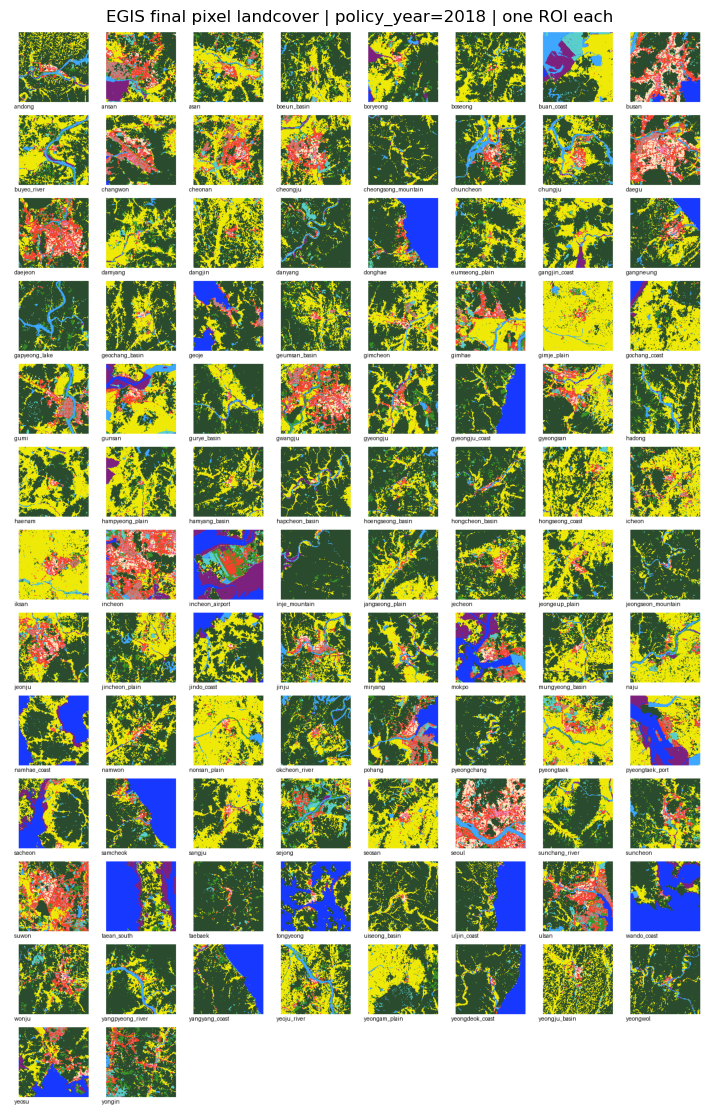

In [9]:
VIS_POLICY_YEAR = 2018
PIXEL_VIS_DIR = EGIS_ROOT / "final_pixel_previews_2018"
PIXEL_VIS_DIR.mkdir(parents=True, exist_ok=True)

legend_items = [(cls, HYBRID_CLASS_NAMES[cls], {**LV1_COLORS, **LV2_COLORS}.get(cls, (0, 0, 0))) for cls in HYBRID_CLASSES]
legend_path = PIXEL_VIS_DIR / "egis_pixel_2018_legend.png"
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for i, (cls, name, color) in enumerate(legend_items):
    ax.add_patch(plt.Rectangle((0, i), 0.8, 0.8, color=np.array(color) / 255.0))
    ax.text(1.0, i + 0.4, f"{cls} {name}", va="center", fontsize=9)
ax.set_xlim(0, 5.8)
ax.set_ylim(0, len(legend_items))
ax.invert_yaxis()
ax.axis("off")
fig.savefig(legend_path, dpi=150)
plt.close(fig)

preview_rows = []
missing = []
thumbs = []
labels = []
for _, row in city_rows.sort_values("city").iterrows():
    city = str(row["city"])
    cache = final_cache_path(city, VIS_POLICY_YEAR)
    if not cache.exists():
        missing.append({"city": city, "policy_year": VIS_POLICY_YEAR, "expected_cache": str(cache)})
        continue
    with np.load(cache, allow_pickle=True) as z:
        lc = z["egis_hybrid_lc_60m"].astype(np.int16)
        nodata = z["egis_source_nodata_mask"].astype(np.uint8) if "egis_source_nodata_mask" in z.files else np.zeros_like(lc, dtype=np.uint8)
        majority = z["egis_source_nodata_majority_fill_mask"].astype(np.uint8) if "egis_source_nodata_majority_fill_mask" in z.files else np.zeros_like(lc, dtype=np.uint8)
    rgba = hybrid_to_rgba(lc)
    out = PIXEL_VIS_DIR / f"egis_pixel_2018_{city}.png"
    Image.fromarray(rgba).save(out)
    preview_rows.append({
        "city": city,
        "policy_year": VIS_POLICY_YEAR,
        "png": str(out.relative_to(DATA_DIR)),
        "nodata_pixels": int(nodata.sum()),
        "majority_fill_pixels": int(majority.sum()),
        "remaining_unknown_pixels": int((lc == 0).sum()),
    })
    thumb = Image.fromarray(rgba).resize((128, 128), Image.Resampling.NEAREST).convert("RGBA")
    thumbs.append(thumb)
    labels.append(city)

preview_df = pd.DataFrame(preview_rows)
preview_csv = REPORT_DIR / "egis_pixel_2018_preview_index.csv"
preview_df.to_csv(preview_csv, index=False, encoding="utf-8-sig")

if missing:
    missing_df = pd.DataFrame(missing)
    missing_csv = REPORT_DIR / "egis_pixel_2018_missing_cache.csv"
    missing_df.to_csv(missing_csv, index=False, encoding="utf-8-sig")
    print("missing 2018 final caches:", len(missing), missing_csv)
else:
    print("all 2018 final caches found:", len(preview_df))

if thumbs:
    cols = 8
    rows_n = int(np.ceil(len(thumbs) / cols))
    tile_w, tile_h = 160, 152
    sheet = Image.new("RGB", (cols * tile_w, rows_n * tile_h), "white")
    from PIL import ImageDraw
    draw = ImageDraw.Draw(sheet)
    for i, (thumb, label) in enumerate(zip(thumbs, labels)):
        x = (i % cols) * tile_w
        y = (i // cols) * tile_h
        sheet.paste(thumb.convert("RGB"), (x + 16, y + 4))
        draw.text((x + 8, y + 134), label[:22], fill=(0, 0, 0))
    sheet_path = PIXEL_VIS_DIR / "egis_pixel_2018_all_rois_contact_sheet.png"
    sheet.save(sheet_path)
    print("individual preview dir:", PIXEL_VIS_DIR)
    print("preview index:", preview_csv)
    print("legend:", legend_path)
    print("contact sheet:", sheet_path)
    plt.figure(figsize=(18, 14))
    plt.imshow(sheet)
    plt.axis("off")
    plt.title("EGIS final pixel landcover | policy_year=2018 | one ROI each")
    plt.show()
else:
    print("no 2018 cache previews generated")
